# 03a — Self-Supervised Pre-Training (SimCLR)

Train the ST-GCN encoder on **ShuttleSet** skeletons using **NT-Xent** (self-supervised contrastive) loss.

- No labels needed — uses all available matches (not just train split)
- Positive pairs = two augmented views of the same skeleton sequence
- All other samples in the batch are negatives

Saved checkpoint: `ssl_pretrained_simclr_{layer}.pt`

In [ ]:
import os, sys, zipfile
from pathlib import Path

# ── Colab detection ───────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    ZIP_PATH     = DRIVE_ROOT / 'baddiev2_colab.zip'

    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project files...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
        print(f'Extracted to {PROJECT_PATH}')
    else:
        print('Project already extracted.')

    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

    # Override paths so outputs go to Drive (not ephemeral /content)
    import src.config as _cfg
    _cfg.MODELS_DIR            = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR           = DRIVE_ROOT / 'results'
    _cfg.SS_SKELETONS_GDINO    = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.FB_SKELETONS_GDINO_V2 = DRIVE_ROOT / 'datasets_preprocessing' / 'finebadminton_skeletons_gdino_v2'
    _cfg.FB_ANNOTATIONS        = (
        DRIVE_ROOT / 'datasets' / 'FineBadminton-dataset' / 'dataset' / # Changed 'Datasets' to 'datasets'
        'transformed_combined_rounds_output_en_evals_translated.json'
    )
    # ── ShuttleSet CSV annotations (shot-type labels for SupCon / §7a eval) ─
    _cfg.SS_CSV_ROOT  = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV = _cfg.SS_CSV_ROOT / 'match.csv'
    # ── Split JSON (inside extracted zip at /content/Baddiev2) ───────────────
    _cfg.SS_SPLIT_JSON = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'

    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    print(f'Drive root   : {DRIVE_ROOT}')
    print(f'Models dir   : {_cfg.MODELS_DIR}')
    print(f'SS skeletons : {_cfg.SS_SKELETONS_GDINO}')
    print(f'FB skeletons : {_cfg.FB_SKELETONS_GDINO_V2}')
    print(f'SS CSV root  : {_cfg.SS_CSV_ROOT}')
    print(f'SS CSV exists: {_cfg.SS_CSV_ROOT.exists()}')
else:
    sys.path.insert(0, os.path.abspath('..'))
    DRIVE_ROOT = Path('..')
    print('Local run — using paths from config.py')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project already extracted.
Drive root   : /content/drive/MyDrive/Baddiev2
Models dir   : /content/drive/MyDrive/Baddiev2/models
SS skeletons : /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
FB skeletons : /content/drive/MyDrive/Baddiev2/datasets_preprocessing/finebadminton_skeletons_gdino_v2
SS CSV root  : /content/drive/MyDrive/Baddiev2/datasets/ShuttleSet/set
SS CSV exists: True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.config import *
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.simclr_loss import NTXentLoss, ProjectionHead, SkeletonAugmentor

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Device: {device}")

Device: cuda


## 1. Configuration

In [ ]:
cfg = get_config('ssl_simclr')

# ── Feature layer toggle ──────────────────────────────────────────────────────
FEATURE_LAYER = 'L2'    # 'L0' | 'L1' | 'L2' | 'L3'
# ─────────────────────────────────────────────────────────────────────────────

# ── Override for quick test runs (comment out if want to use config.py) ──────────────
cfg.ssl.epochs = 100
cfg.data.shot_window = 32   # T=32 frames per shot (covers P75 of shot intervals)
cfg.stgcn.in_channels = FEATURE_DIMS[FEATURE_LAYER]
cfg.ssl.temperature = 0.2
cfg.ssl.jitter_std     = 0.02     # was 0.06 — gentler Gaussian noise
cfg.ssl.mask_ratio     = 0.15     # was 0.40 — keep ~85% of joints (graph stays connected)
cfg.ssl.speed_range    = 0.20     # was 0.30 — narrower temporal resampling
cfg.ssl.rotation_range = 10       # was 25   — subtle rotation, preserves court orientation


# ─────────────────────────────────────────────────────────────────────────────

feature_dim = FEATURE_DIMS[FEATURE_LAYER]
cfg.stgcn.in_channels = feature_dim

print(f"Feature layer : {FEATURE_LAYER} ({feature_dim} features/node)")
print(f"SSL method    : SimCLR (NT-Xent, self-supervised)")
print(f"\nEncoder: ST-GCN")
print(f"  in_channels  : {cfg.stgcn.in_channels}")
print(f"  num_nodes    : {cfg.stgcn.num_nodes}")
print(f"  embedding_dim: {cfg.stgcn.embedding_dim}")
print(f"\nSSL config:")
print(f"  temperature  : {cfg.ssl.temperature}")
print(f"  epochs       : {cfg.ssl.epochs}")
print(f"  batch_size   : {cfg.ssl.batch_size}")
print(f"  speed_range  : {cfg.ssl.speed_range}")
print(f"  rotation     : {cfg.ssl.rotation_range}")

Feature layer : L2 (9 features/node)
SSL method    : SimCLR (NT-Xent, self-supervised)

Encoder: ST-GCN
  in_channels  : 9
  num_nodes    : 34
  embedding_dim: 256

SSL config:
  temperature  : 0.2
  epochs       : 100
  batch_size   : 64
  speed_range  : 0.2
  rotation     : 10


## 2. Build Model Components

In [ ]:
# Build graph adjacency
graph_builder = GraphBuilder(
    use_inter_player=cfg.ablation.use_inter_player,
    single_player=cfg.ablation.single_player,
)
adjacency = graph_builder.build_adjacency().to(device)
print(f"Adjacency: {adjacency.shape}")

# Build encoder
encoder = STGCN(
    in_channels=cfg.stgcn.in_channels,
    num_nodes=cfg.stgcn.num_nodes,
    adjacency=adjacency,
    num_layers=cfg.stgcn.num_layers,
    base_channels=cfg.stgcn.base_channels,
    embedding_dim=cfg.stgcn.embedding_dim,
    temporal_kernel=cfg.stgcn.temporal_kernel,
    dropout=cfg.stgcn.dropout,
).to(device)

# Projection head
projector = ProjectionHead(
    embedding_dim=cfg.stgcn.embedding_dim,
    hidden_dim=cfg.ssl.projection_hidden,
    projection_dim=cfg.ssl.projection_dim,
).to(device)

# NT-Xent loss (self-supervised — no labels needed)
contrastive_loss = NTXentLoss(temperature=cfg.ssl.temperature)
print(f"Loss: NTXentLoss (self-supervised, no labels)")

augmentor = SkeletonAugmentor(
    jitter_std=cfg.ssl.jitter_std,
    mask_ratio=cfg.ssl.mask_ratio,
    speed_range=cfg.ssl.speed_range,
    rotation_range=cfg.ssl.rotation_range,
)

params = list(encoder.parameters()) + list(projector.parameters())
optimizer = optim.AdamW(params, lr=cfg.ssl.lr, weight_decay=cfg.ssl.weight_decay)

total_params = sum(p.numel() for p in encoder.parameters())
print(f"\nEncoder parameters: {total_params:,}")
print(f"Total trainable   : {sum(p.numel() for p in params):,}")

Adjacency: torch.Size([3, 34, 34])
Loss: NTXentLoss (self-supervised, no labels)

Encoder parameters: 3,083,199
Total trainable   : 3,182,399


/content/Baddiev2/src/data/graph_builder.py:147: RuntimeWarning: divide by zero encountered in power
  D_inv_sqrt = np.where(D > 0, np.power(D, -0.5), 0)


## 3. Load Data

SimCLR uses **all** available ShuttleSet matches (no split filtering) since it does not require labels.

In [ ]:
## Inspect available skeletons before loading dataset
from src.config import SS_SKELETONS_GDINO

skel_root = SS_SKELETONS_GDINO
print(f"Skeleton dir: {skel_root}")
print(f"Exists: {skel_root.exists()}\n")

match_dirs = sorted([d for d in skel_root.iterdir() if d.is_dir()]) if skel_root.exists() else []
print(f"{'Match':<65} {'skeletons.npy':>14} {'frame_nums.npy':>15} {'Frames':>8}")
print("-" * 105)
total_frames = 0
for d in match_dirs:
    has_sk = (d / 'skeletons.npy').exists()
    has_fn = (d / 'frame_nums.npy').exists()
    n_frames = 0
    if has_fn:
        n_frames = len(np.load(str(d / 'frame_nums.npy')))
        total_frames += n_frames
    sk_str = f"{np.load(str(d / 'skeletons.npy')).shape}" if has_sk else "missing"
    fn_str = str(n_frames) if has_fn else "missing"
    print(f"  {d.name:<63} {sk_str:>14} {fn_str:>15} {n_frames:>8}")

print(f"\nTotal matches: {len(match_dirs)}  |  Total frames with skeletons: {total_frames:,}")

Skeleton dir: /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
Exists: True

Match                                                              skeletons.npy  frame_nums.npy   Frames
---------------------------------------------------------------------------------------------------------
  1 empty                                                                missing         missing        0
  2 bad quality                                                          missing         missing        0
  Anders_ANTONSEN_Jonatan_CHRISTIE Indonesia_Masters_2020_QuarterFinals  (2, 1018, 34)            1018     1018
  Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals  (2, 6715, 34)            6715     6715
  Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final  (2, 5347, 34)            5347     5347
  Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals  (2, 3307, 34)            3307     3307
  Anthony_Sin

In [ ]:
from src.config import SS_SKELETONS_GDINO

# SimCLR: no split — use ALL matches (no labels needed)
# To ensure the patched _load_whole_match_index is called, set load_shot_types=True
dataset = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO,
    shot_window=cfg.data.shot_window,
    feature_layer=FEATURE_LAYER,
    load_shot_types=True, # Changed from False to True
    split=None,
)
print(f"Dataset size: {len(dataset)} samples (all matches, no split)")

# Sanity check
if len(dataset) > 0: # Add this check
    sample = dataset[0]
    x = sample[0] if isinstance(sample, tuple) else sample
    has_data = x.abs().sum() > 0
    print(f"Sample shape: {x.shape}, has_data: {has_data})")
else: # Add this else block
    print("Warning: Dataset is empty, cannot perform sanity check on sample[0].")
    print("Please check the implementation of ShuttleSetDataset._load_whole_match_skeletons.")


[INFO] ShuttleSet split='None': 7051 shots from whole-match skeletons across 7 match(es)
Dataset size: 7051 samples (all matches, no split)
Sample shape: torch.Size([9, 32, 34]), has_data: True)


In [ ]:
def simclr_collate(batch):
    """Collate for SimCLR — no labels needed."""
    if isinstance(batch[0], tuple):
        xs = [b[0] for b in batch]
    else:
        xs = batch
    return torch.stack(xs)

dataloader = DataLoader(
    dataset,
    batch_size=cfg.ssl.batch_size,
    shuffle=True,
    num_workers=0,   # set to 4 on Colab
    pin_memory=True,
    drop_last=True,
    collate_fn=simclr_collate,
)
print(f"Batches per epoch: {len(dataloader)}")

Batches per epoch: 110


## 3b. Visualisations: SimCLR Augmentation Pipeline

Two diagnostic views before training:

1. **Augmentation pipeline** — what two different "views" of the same shot look like as skeleton stick figures
2. **Positive-pair structure** — SimCLR only has 1 positive per anchor (the augmentation twin)

> These cells are diagnostic only and do not affect training.

In [ ]:
# ── Viz 1: Augmentation pipeline — multi-frame ghost trail ────────────────────
# Plots N_VIZ evenly-spaced frames per subplot so temporal augmentations
# (speed perturbation) are visible as tighter/looser frame spacing.
import matplotlib.patches as mpatches

_COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

N_VIZ = 5                       # number of frames to overlay per subplot

def _draw_player(ax, xy17, color, valid_mask, alpha=1.0, lw=2):
    """Draw skeleton using pre-computed per-joint validity mask.
    Validity must be derived from the ORIGINAL (pre-augmentation) skeleton
    so that jitter noise on zero joints does not create spurious lines.
    """
    for j1, j2 in _COCO_EDGES:
        if valid_mask[j1] and valid_mask[j2]:
            ax.plot([xy17[j1,0], xy17[j2,0]], [-xy17[j1,1], -xy17[j2,1]],
                    '-', color=color, lw=lw, alpha=alpha)
    for j in range(17):
        if valid_mask[j]:
            ax.scatter(xy17[j,0], -xy17[j,1], s=20, c=color, alpha=alpha, zorder=5)

def _get_frame_xy_and_valid(orig_tensor, aug_tensor, frame_idx):
    """Extract (P0_17x2, P1_17x2, valid_P0, valid_P1) at a given frame.
    Validity = non-zero in ORIGINAL & non-zero in augmented (catches explicit masking).
    """
    orig_xy = orig_tensor[:2, frame_idx, :].T.numpy()  # (34, 2)
    aug_xy  = aug_tensor[:2,  frame_idx, :].T.numpy()  # (34, 2)
    orig_valid = np.array([abs(orig_xy[j,0]) + abs(orig_xy[j,1]) > 1e-4 for j in range(34)])
    aug_valid  = np.array([abs(aug_xy[j,0])  + abs(aug_xy[j,1])  > 1e-4 for j in range(34)])
    valid = orig_valid & aug_valid
    return aug_xy[:17], aug_xy[17:], valid[:17], valid[17:]

def _draw_sequence(ax, orig_tensor, aug_tensor, n_frames=N_VIZ):
    """Draw n_frames evenly spaced across temporal axis with fading alpha.
    Validity is computed per-frame from the original tensor to avoid jitter artefacts.
    """
    T = aug_tensor.shape[1]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    alphas  = np.linspace(0.15, 1.0, n_frames)      # earliest = faint, latest = solid
    for frame_idx, alpha in zip(indices, alphas):
        p0, p1, v0, v1 = _get_frame_xy_and_valid(orig_tensor, aug_tensor, frame_idx)
        _draw_player(ax, p0, color='royalblue', valid_mask=v0, alpha=alpha, lw=1.5)
        _draw_player(ax, p1, color='tomato',    valid_mask=v1, alpha=alpha, lw=1.5)

# Find a non-zero sample
raw_x = None
for i in range(len(dataset)):
    sample = dataset[i]
    x_i = sample[0] if isinstance(sample, tuple) else sample
    if x_i.abs().sum() > 0:
        raw_x = x_i; break
assert raw_x is not None

_aug_full = SkeletonAugmentor(
    jitter_std=cfg.ssl.jitter_std, mask_ratio=cfg.ssl.mask_ratio,
    speed_range=cfg.ssl.speed_range, rotation_range=cfg.ssl.rotation_range,
)
_aug_variants = {
    'Original\n(raw skeleton)': raw_x,
    f'Jitter\n(\u03c3={cfg.ssl.jitter_std})':
        SkeletonAugmentor(jitter_std=cfg.ssl.jitter_std, mask_ratio=0, speed_range=0, rotation_range=0)(raw_x),
    f'Speed perturb\n({1-cfg.ssl.speed_range:.1f}x\u2013{1+cfg.ssl.speed_range:.1f}x)':
        SkeletonAugmentor(jitter_std=0, mask_ratio=0, speed_range=cfg.ssl.speed_range, rotation_range=0)(raw_x),
    f'Rotation\n(\u00b1{cfg.ssl.rotation_range}\u00b0)':
        SkeletonAugmentor(jitter_std=0, mask_ratio=0, speed_range=0, rotation_range=cfg.ssl.rotation_range)(raw_x),
    f'Joint masking\n({int(cfg.ssl.mask_ratio*100)}% zeroed)':
        SkeletonAugmentor(jitter_std=0, mask_ratio=cfg.ssl.mask_ratio, speed_range=0, rotation_range=0)(raw_x),
    'View A\n(all augs)':  _aug_full(raw_x),
    'View B\n(all augs)':  _aug_full(raw_x),
}

fig, axes = plt.subplots(1, len(_aug_variants), figsize=(3.5 * len(_aug_variants), 5))
fig.suptitle(
    f'SimCLR Augmentation Pipeline \u2014 {N_VIZ}-Frame Ghost Trail per View\n'
    'Blue = Player 1 (top court)  |  Red = Player 2 (bottom court)\n'
    'Faint \u2192 solid = early \u2192 late frame',
    fontsize=11, fontweight='bold', y=1.04,
)

for ax, (title, x_aug) in zip(axes, _aug_variants.items()):
    _draw_sequence(ax, raw_x, x_aug)   # pass raw_x for validity reference
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

for ax in axes[-2:]:
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(3); spine.set_edgecolor('#2ca02c')
    ax.set_facecolor('#f0fff0')

green_patch = mpatches.Patch(facecolor='#f0fff0', edgecolor='#2ca02c', lw=2,
                              label='Encoder input pair (both views of same shot)')
fig.legend(handles=[green_patch], loc='lower center', fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'ssl_simclr_viz_augmentation_views.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/ssl_simclr_viz_augmentation_views.png")


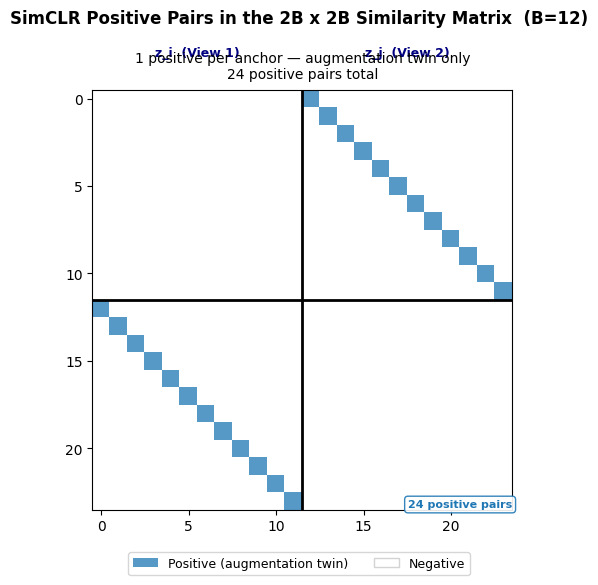

SimCLR: 1 positive per anchor (constant)
Saved: results/ssl_simclr_viz_positive_pairs.png


In [ ]:
# ── Viz 2: SimCLR positive-pair structure ─────────────────────────────────────
# SimCLR: each anchor has exactly 1 positive (its augmentation twin).

_NPC, _CLS = 4, ['Smash', 'Clear', 'Drive']
_B   = _NPC * len(_CLS)

_sc = np.zeros((2*_B, 2*_B), bool)
for _i in range(_B):
    _sc[_i, _i+_B] = _sc[_i+_B, _i] = True

fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))
fig.suptitle(f'SimCLR Positive Pairs in the 2B x 2B Similarity Matrix  (B={_B})',
             fontsize=12, fontweight='bold')

bg = np.ones((2*_B, 2*_B, 4))
bg[_sc] = [0.12, 0.47, 0.71, 0.75]  # blue
ax.imshow(bg, interpolation='none')
ax.axhline(_B-0.5, color='black', lw=2)
ax.axvline(_B-0.5, color='black', lw=2)
ax.text(_B/2-0.5,    -2.4, 'z_i  (View 1)', ha='center', fontsize=9, color='navy', fontweight='bold')
ax.text(_B+_B/2-0.5, -2.4, 'z_j  (View 2)', ha='center', fontsize=9, color='navy', fontweight='bold')
ax.set_title(f'1 positive per anchor — augmentation twin only\n{int(_sc.sum())} positive pairs total',
             fontsize=10, pad=8)
ax.text(2*_B-0.5, 2*_B-0.5, f'{int(_sc.sum())} positive pairs',
        ha='right', va='bottom', fontsize=8, color='#1f77b4', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#1f77b4', alpha=0.9))

fig.legend(handles=[
    mpatches.Patch(fc='#1f77b4', alpha=0.75, label='Positive (augmentation twin)'),
    mpatches.Patch(fc='white', ec='lightgray', label='Negative'),
], loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ssl_simclr_viz_positive_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("SimCLR: 1 positive per anchor (constant)")
print("Saved: results/ssl_simclr_viz_positive_pairs.png")

## 4. Training Loop

In [ ]:
history = {'loss': [], 'epoch': []}

# Early stopping config
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
best_loss = float('inf')
no_improve_count = 0

for epoch in range(cfg.ssl.epochs):
    encoder.train()
    projector.train()

    epoch_loss = 0.0

    for x_batch in tqdm(dataloader, desc=f'Epoch {epoch+1}/{cfg.ssl.epochs}', leave=False):
        x = x_batch.to(device)   # (B, C, T, V)

        # Two augmented views
        x_i = torch.stack([augmentor(xi) for xi in x])
        x_j = torch.stack([augmentor(xi) for xi in x])

        h_i = encoder(x_i)   # (B, embedding_dim)
        h_j = encoder(x_j)

        z_i = projector(h_i)
        z_j = projector(h_j)

        loss = contrastive_loss(z_i, z_j)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    history['loss'].append(avg_loss)
    history['epoch'].append(epoch + 1)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{cfg.ssl.epochs} | loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - EARLY_STOP_MIN_DELTA:
        best_loss = avg_loss
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

print(f"Training complete. Best loss: {best_loss:.4f}")

Epoch   5/100 | loss: 0.6981


Epoch  10/100 | loss: 0.6737


Epoch  15/100 | loss: 0.6642


Epoch  20/100 | loss: 0.6578


Epoch  25/100 | loss: 0.6535


...

Epoch  75/100 | loss: 0.6437


Epoch  80/100 | loss: 0.6405


Epoch  85/100 | loss: 0.6415


Epoch  90/100 | loss: 0.6400



Early stopping at epoch 93 (no improvement for 10 epochs)
Training complete. Best loss: 0.6398


## 5. Save Weights

In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'encoder_state_dict': encoder.state_dict(),
    'projector_state_dict': projector.state_dict(),
    'feature_layer': FEATURE_LAYER,
    'ssl_method': 'simclr',
    'config': cfg,
    'history': history,
}

ckpt_path = MODELS_DIR / f'ssl_pretrained_simclr_{FEATURE_LAYER}_14Mar.pt'
torch.save(checkpoint, ckpt_path)
print(f"Saved: {ckpt_path}")

Saved: /content/drive/MyDrive/Baddiev2/models/ssl_pretrained_simclr_L2_14Mar.pt


## 6. Training Curves

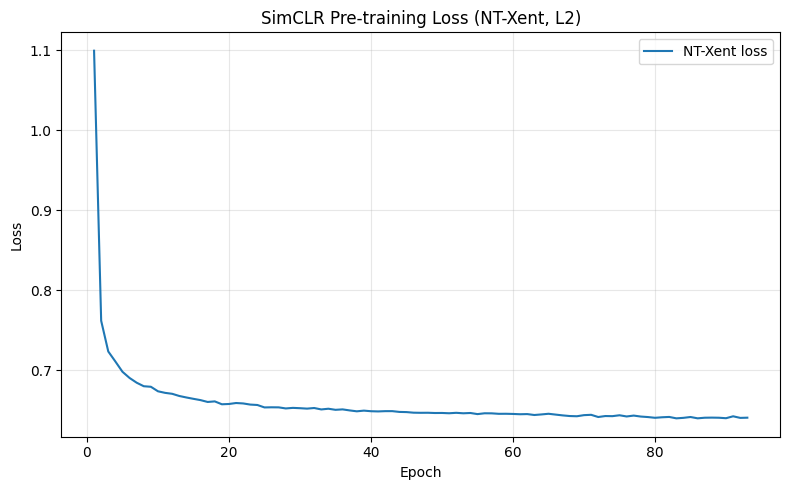

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(history['epoch'], history['loss'], label='NT-Xent loss', color='#1f77b4')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'SimCLR Pre-training Loss (NT-Xent, {FEATURE_LAYER})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'ssl_simclr_loss_{FEATURE_LAYER}.png', dpi=150)
plt.show()

## 7. Proxy Evaluation

**Linear probe on FineBadminton strategy labels** — cross-validated logistic regression.
Sanity-check that the SimCLR representation transfers to the downstream task.

In [ ]:
from src.config import FB_ANNOTATIONS

print(f"FB_ANNOTATIONS path: {FB_ANNOTATIONS}")
print(f"File exists: {FB_ANNOTATIONS.exists()}")


FB_ANNOTATIONS path: /content/drive/MyDrive/Baddiev2/datasets/FineBadminton-dataset/dataset/transformed_combined_rounds_output_en_evals_translated.json
File exists: True


In [ ]:
import json
from src.config import FB_ANNOTATIONS

print(f"Reading content from: {FB_ANNOTATIONS}")
if FB_ANNOTATIONS.exists():
    with open(FB_ANNOTATIONS, 'r') as f:
        content = json.load(f)
    print(f"File content (first 1000 chars):\n{json.dumps(content, indent=2)[:1000]}...")
    print(f"Total items in JSON: {len(content)}")
else:
    print("File does not exist, cannot read content.")


Reading content from: /content/drive/MyDrive/Baddiev2/datasets/FineBadminton-dataset/dataset/transformed_combined_rounds_output_en_evals_translated.json
File content (first 1000 chars):
[
  {
    "video": "0011_001.mp4",
    "resolution": {
      "width": 1280,
      "height": 720
    },
    "fps": 25.0,
    "duration_frames": 327,
    "start_frame": 16362,
    "end_frame": 16688,
    "hitting": [
      {
        "start_frame": 16362,
        "end_frame": 16378,
        "player": "Kento MOMOTA",
        "hit_type": "serve",
        "subtype": [
          "short serve"
        ],
        "quality": "4",
        "comment": "top player a backhand short serve",
        "hit_frame": 16363,
        "get_point": [],
        "ball_area": "mid front court",
        "hitter": "top",
        "player_actions": [
          "backhand"
        ],
        "shot_characteristics": [
          "cross-court"
        ]
      },
      {
        "start_frame": 16378,
        "end_frame": 16400,
        "play

In [ ]:
from src.data.dataset import FineBadmintonDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def extract_embeddings(ds, enc, dev):
    enc.eval()
    embs, labs = [], []
    with torch.no_grad():
        for i in range(len(ds)):
            sample = ds[i]
            x, y = sample if isinstance(sample, tuple) else (sample, -1)
            if y < 0:
                continue
            emb = enc(x.unsqueeze(0).to(dev)).cpu().numpy()[0]
            embs.append(emb)
            labs.append(y)
    return np.array(embs), np.array(labs)

fb_ds = FineBadmintonDataset(feature_layer=FEATURE_LAYER)
print(f"FineBadminton: {len(fb_ds)} samples")

fb_embs, fb_labs = extract_embeddings(fb_ds, encoder, device)
print(f"Embeddings: {fb_embs.shape}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = []
for train_idx, test_idx in skf.split(fb_embs, fb_labs):
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(fb_embs[train_idx], fb_labs[train_idx])
    preds = clf.predict(fb_embs[test_idx])
    fold_f1s.append(f1_score(fb_labs[test_idx], preds, average='macro'))

print(f"\nFB Strategy Linear Probe Macro-F1: {np.mean(fold_f1s):.3f} +/- {np.std(fold_f1s):.3f}")
print(f"Per-fold: {[f'{f:.3f}' for f in fold_f1s]}")

[INFO] FineBadminton: loaded court homography from H_img_to_court_m.npy
[INFO] FineBadminton: 296 labeled shots across 40 rallies
  intercept: 108
  create_depth: 61
  defensive: 59
  passive: 50
  move_to_net: 18
FineBadminton: 296 samples
Embeddings: (296, 256)

FB Strategy Linear Probe Macro-F1: 0.107 +/- 0.002
Per-fold: ['0.104', '0.109', '0.109', '0.109', '0.105']


In [ ]:
import src.data.dataset
from src.config import FB_ANNOTATIONS

print(f"FB_ANNOTATIONS in src.data.dataset BEFORE update: {src.data.dataset.FB_ANNOTATIONS}")

# Update the FB_ANNOTATIONS path within the src.data.dataset module
src.data.dataset.FB_ANNOTATIONS = FB_ANNOTATIONS

print(f"FB_ANNOTATIONS in src.data.dataset AFTER update:  {src.data.dataset.FB_ANNOTATIONS}")

# You might need to re-initialize the FineBadmintonDataset if it was already created
# However, the next cell will re-create it, so this might not be strictly necessary
# if you re-run the whole proxy evaluation section.

FB_ANNOTATIONS in src.data.dataset BEFORE update: /content/drive/MyDrive/Baddiev2/datasets/FineBadminton-dataset/dataset/transformed_combined_rounds_output_en_evals_translated.json
FB_ANNOTATIONS in src.data.dataset AFTER update:  /content/drive/MyDrive/Baddiev2/datasets/FineBadminton-dataset/dataset/transformed_combined_rounds_output_en_evals_translated.json
